In [1]:
# Install library
!pip install nltk scikit-learn pandas matplotlib seaborn tensorflow

# Import library
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout, concatenate, Embedding
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import nltk

# Download NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')

print(" Semua library berhasil diimport!")
print(f"TensorFlow version: {tf.__version__}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


 Semua library berhasil diimport!
TensorFlow version: 2.20.0


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [2]:
from google.colab import files

print(" Silakan upload file CSV dataset ")
uploaded = files.upload()

for filename in uploaded.keys():
    df = pd.read_csv(filename)
    print(f" File '{filename}' berhasil dimuat!")

print(f"\n Jumlah data: {len(df)} baris")
print(df.head())

 Silakan upload file CSV dataset 


Saving dataset_clickbait.csv to dataset_clickbait.csv
 File 'dataset_clickbait.csv' berhasil dimuat!

 Jumlah data: 8613 baris
                                               title          label  \
0  Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...  non-clickbait   
1  Malaysia Sudutkan RI: Isu Kabut Asap hingga In...  non-clickbait   
2  Viral! Driver Ojol di Bekasi Antar Pesanan Mak...      clickbait   
3  Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...  non-clickbait   
4  MPR: Amandemen UUD 1945 Tak Akan Melebar ke Ma...  non-clickbait   

   label_score  
0            0  
1            0  
2            1  
3            0  
4            0  


In [3]:
def extract_features(title):
    """
    Ekstraksi fitur-fitur dari judul berita:
    - Jumlah tanda baca
    - Jumlah huruf kapital
    - Jumlah huruf kecil
    - Jumlah angka
    """
    if not isinstance(title, str):
        title = str(title)

    # 1. Jumlah tanda baca
    punctuation = r'[!""#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~]'
    num_punctuation = len(re.findall(punctuation, title))

    # 2. Jumlah huruf kapital
    num_uppercase = sum(1 for c in title if c.isupper())

    # 3. Jumlah huruf kecil
    num_lowercase = sum(1 for c in title if c.islower())

    # 4. Jumlah angka
    num_digits = sum(1 for c in title if c.isdigit())

    # 5. Panjang teks (tambahan)
    text_length = len(title)

    # 6. Jumlah kata (tambahan)
    num_words = len(title.split())

    return {
        'num_punctuation': num_punctuation,
        'num_uppercase': num_uppercase,
        'num_lowercase': num_lowercase,
        'num_digits': num_digits,
        'text_length': text_length,
        'num_words': num_words
    }

print("_"*50)
print("EKSTRAKSI FITUR BARU")
print("_"*50)

feature_list = []
for title in df['title']:
    feature_list.append(extract_features(title))

features_df = pd.DataFrame(feature_list)
df = pd.concat([df, features_df], axis=1)

print(f"\n Berhasil mengekstrak {len(features_df.columns)} fitur baru!")
print(f"\nFitur-fitur yang ditambahkan:")
for col in features_df.columns:
    print(f"   - {col}")

__________________________________________________
EKSTRAKSI FITUR BARU
__________________________________________________

 Berhasil mengekstrak 6 fitur baru!

Fitur-fitur yang ditambahkan:
   - num_punctuation
   - num_uppercase
   - num_lowercase
   - num_digits
   - text_length
   - num_words


In [6]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download stopwords
nltk.download('stopwords')

# Setup stopwords
stop_words = set(stopwords.words('indonesian'))
additional_stops = {'yg', 'dgn', 'tdk', 'jd', 'utk', 'aja', 'sih', 'kok', 'nya', 'dan', 'ini', 'itu'}
stop_words.update(additional_stops)

stemmer = PorterStemmer()

def clean_text(text):
    """Membersihkan teks judul berita"""
    if not isinstance(text, str):
        text = str(text)

    # Lowercase
    text = text.lower()
    # Hapus karakter non-alfabet
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Tokenisasi
    tokens = word_tokenize(text)
    # Hapus stopwords dan stemming
    tokens = [stemmer.stem(token) for token in tokens if token not in stop_words and len(token) > 2]

    return ' '.join(tokens)

print("_"*50)
print("PREPROCESSING & CLEANING DATA")
print("_"*50)

# Membersihkan data di kolom title
df['clean_title'] = df['title'].apply(clean_text)

print(f"\n Data di kolom 'title' telah dibersihkan!")
print(f"\nContoh hasil:")
for i in range(8613):
    print(f"\nOriginal  : {df['title'].iloc[i]}")
    print(f"Cleaned   : {df['clean_title'].iloc[i]}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Output streaming akan dipotong hingga 5000 baris terakhir.
Original  : Pemakaman BJ Habibie, Polisi Akan Tutup Jalan Menuju TMP Kalibata
Cleaned   : pemakaman habibi polisi tutup jalan tmp kalibata

Original  : 1.316 Titik Panas di Sumatera, Wagub Riau Ajak Salat Istisqa
Cleaned   : titik pana sumatera wagub riau ajak salat istisqa

Original  : BJ Habibie Meninggal, Wakil PM Singapura Ucapkan Duka Cita
Cleaned   : habibi meningg wakil singapura ucapkan duka cita

Original  : Tol Cikampek Elevated Diusulkan Khusus untuk Mobil dan Bus
Cleaned   : tol cikampek elev diusulkan khusu mobil bu

Original  : Anggota BPK Akan Ditetapkan Usai Uji Kelayakan Terakhir, Selasa
Cleaned   : anggota bpk ditetapkan uji kelayakan selasa

Original  : Unpad Rayakan 62 Tahun: Kejar Akreditasi, Peringkat Internasional
Cleaned   : unpad rayakan kejar akreditasi peringkat internasion

Original  : Dokter: Lensa Kontak dan Kurang Minum Bikin Mata Kering
Cleaned   : dokter lensa kontak minum bikin mata kere

Origi

In [7]:
# FITUR NUMERIK
numeric_features = ['num_punctuation', 'num_uppercase', 'num_lowercase',
                    'num_digits', 'text_length', 'num_words']

X_numeric = df[numeric_features].values

# Standardisasi fitur numerik
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)

#  FITUR TEKS
MAX_FEATURES = 10000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_FEATURES, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_title'])
X_text_seq = tokenizer.texts_to_sequences(df['clean_title'])
X_text_pad = sequence.pad_sequences(X_text_seq, maxlen=MAX_LEN, padding='post', truncating='post')

#  LABEL
le = LabelEncoder()
y = le.fit_transform(df['label'])  # clickbait=1, non-clickbait=0

print("="*50)
print("PERSIAPAN DATA")
print("="*50)
print(f"\nFitur Numerik shape: {X_numeric_scaled.shape}")
print(f"Fitur Teks shape: {X_text_pad.shape}")
print(f"Label shape: {y.shape}")
print(f"\nDistribusi label:")
print(f"   Non-Clickbait (0): {(y==0).sum()}")
print(f"   Clickbait (1): {(y==1).sum()}")

PERSIAPAN DATA

Fitur Numerik shape: (8613, 6)
Fitur Teks shape: (8613, 100)
Label shape: (8613,)

Distribusi label:
   Non-Clickbait (0): 3316
   Clickbait (1): 5297


In [8]:
# Split data (80% training, 20% testing)
X_num_train, X_num_test, X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_numeric_scaled, X_text_pad, y, test_size=0.2, random_state=42, stratify=y
)

print("_"*50)
print("TRAIN TEST SPLIT")
print("_"*50)
print(f"\nTraining set: {len(y_train)} data ({len(y_train)/len(y)*100:.1f}%)")
print(f"Testing set : {len(y_test)} data ({len(y_test)/len(y)*100:.1f}%)")
print(f"\nDistribusi training:")
print(f"   Non-Clickbait: {(y_train==0).sum()}")
print(f"   Clickbait: {(y_train==1).sum()}")

__________________________________________________
TRAIN TEST SPLIT
__________________________________________________

Training set: 6890 data (80.0%)
Testing set : 1723 data (20.0%)

Distribusi training:
   Non-Clickbait: 2653
   Clickbait: 4237


In [11]:
#  PREPROCESSING LANJUTAN
# Normalisasi tambahan untuk data testing (tidak perlu diubah, sudah dilakukan di atas)

# Cek apakah data testing sudah siap
print("_"*50)
print("PREPROCESSING LANJUTAN UNTUK TESTING")
print("_"*50)

print(f"\n Data testing siap digunakan!")
print(f"   - X_num_test shape: {X_num_test.shape}")
print(f"   - X_text_test shape: {X_text_test.shape}")
print(f"   - y_test shape: {y_test.shape}")

# Contoh data testing pertama (kode yang sudah diperbaiki)
print(f"\nContoh data testing pertama:")
if len(df) > 0:
    print(f"   - Label: {y_test[0]}")
    print(f"   - (1=Clickbait, 0=Non-Clickbait)")
else:
    print("   - Data tidak tersedia")

__________________________________________________
PREPROCESSING LANJUTAN UNTUK TESTING
__________________________________________________

 Data testing siap digunakan!
   - X_num_test shape: (1723, 6)
   - X_text_test shape: (1723, 100)
   - y_test shape: (1723,)

Contoh data testing pertama:
   - Label: 1
   - (1=Clickbait, 0=Non-Clickbait)


In [12]:
# Hitung class weight untuk mengatasi data tidak seimbang
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print("_"*50)
print("PEMBOBOTAN CLASS (CLASS WEIGHT)")
print("_"*50)
print(f"\nDistribusi training:")
print(f"   Non-Clickbait (0): {(y_train==0).sum()} data")
print(f"   Clickbait (1): {(y_train==1).sum()} data")
print(f"\nClass weight yang dihitung:")
print(f"   Non-Clickbait (0): {class_weights[0]:.4f}")
print(f"   Clickbait (1): {class_weights[1]:.4f}")

__________________________________________________
PEMBOBOTAN CLASS (CLASS WEIGHT)
__________________________________________________

Distribusi training:
   Non-Clickbait (0): 2653 data
   Clickbait (1): 4237 data

Class weight yang dihitung:
   Non-Clickbait (0): 1.2985
   Clickbait (1): 0.8131


In [13]:
#  PARAMETER
VOCAB_SIZE = min(MAX_FEATURES, len(tokenizer.word_index) + 1)
EMBEDDING_DIM = 128
LSTM_UNITS = 64
DROPOUT_RATE = 0.3

# INPUT 1: TEKS
text_input = Input(shape=(MAX_LEN,), name='text_input')
embedding_layer = Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN)(text_input)
lstm_layer = LSTM(LSTM_UNITS, dropout=DROPOUT_RATE, return_sequences=False)(embedding_layer)
text_dropout = Dropout(DROPOUT_RATE)(lstm_layer)
text_output = Dense(32, activation='relu')(text_dropout)

#  INPUT 2: FITUR NUMERIK
numeric_input = Input(shape=(X_num_train.shape[1],), name='numeric_input')
numeric_dense = Dense(32, activation='relu')(numeric_input)
numeric_dropout = Dropout(DROPOUT_RATE)(numeric_dense)
numeric_output = Dense(16, activation='relu')(numeric_dropout)

# GABUNGKAN KEDUA INPUT
concat = concatenate([text_output, numeric_output])

#  LAYER FULLY CONNECTED
hidden1 = Dense(64, activation='relu')(concat)
dropout1 = Dropout(DROPOUT_RATE)(hidden1)
hidden2 = Dense(32, activation='relu')(dropout1)
dropout2 = Dropout(DROPOUT_RATE)(hidden2)

#  OUTPUT
output = Dense(1, activation='sigmoid', name='output')(dropout2)

#  BUILD MODEL
model = Model(inputs=[text_input, numeric_input], outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("_"*50)
print("ARSITEKTUR MULTI INPUT NEURAL NETWORK")
print("_"*50)
model.summary()

# Visualisasi model
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
print("\n Arsitektur model disimpan ke 'model_architecture.png'")

__________________________________________________
ARSITEKTUR MULTI INPUT NEURAL NETWORK
__________________________________________________


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 128)  │  1,280,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     49,408 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        224 │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      3,136 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,337,489 (5.10 MB)

 Trainable params: 1,337,489 (5.10 MB)

 Non-trainable params: 0 (0.00 B)


 Arsitektur model disimpan ke 'model_architecture.png'


In [14]:
# stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("_"*50)
print("TRAINING MULTI INPUT NEURAL NETWORK")
print("_"*50)

history = model.fit(
    [X_text_train, X_num_train],
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

print("\n Training selesai!")

__________________________________________________
TRAINING MULTI INPUT NEURAL NETWORK
__________________________________________________
Epoch 1/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 20s 87ms/step - accuracy: 0.6226 - loss: 0.6504 - precision: 0.7158 - recall: 0.6370 - val_accuracy: 0.6930 - val_loss: 0.6169 - val_precision: 0.7514 - val_recall: 0.7593
Epoch 2/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - accuracy: 0.6780 - loss: 0.6325 - precision: 0.7208 - recall: 0.7744 - val_accuracy: 0.7170 - val_loss: 0.6019 - val_precision: 0.7516 - val_recall: 0.8163
Epoch 3/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 15s 86ms/step - accuracy: 0.6838 - loss: 0.6170 - precision: 0.7320 - recall: 0.7634 - val_accuracy: 0.7213 - val_loss: 0.5956 - val_precision: 0.7621 - val_recall: 0.8047
Epoch 4/30
173/173 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - accuracy: 0.6796 - loss: 0.6177 - precision: 0.7368 - recall: 0.7421 - val_accuracy: 0.7155 - val_loss: 0.5991 - val_precision: 0.7671 - val_recall: 0.7814
Epoch 5/30
173

54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step
__________________________________________________
EVALUASI MODEL
__________________________________________________

 Akurasi Model: 0.7237 (72.37%)

 Classification Report:
               precision    recall  f1-score   support

Non-Clickbait       0.65      0.62      0.63       663
    Clickbait       0.77      0.79      0.78      1060

     accuracy                           0.72      1723
    macro avg       0.71      0.70      0.71      1723
 weighted avg       0.72      0.72      0.72      1723



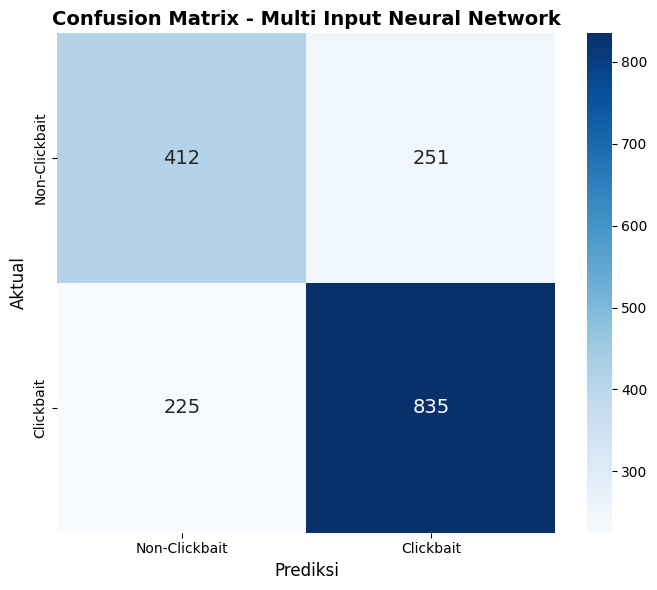

In [15]:
# Prediksi pada data testing
y_pred_prob = model.predict([X_text_test, X_num_test])
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Metrik evaluasi
accuracy = accuracy_score(y_test, y_pred)

print("_"*50)
print("EVALUASI MODEL")
print("_"*50)
print(f"\n Akurasi Model: {accuracy:.4f} ({accuracy*100:.2f}%)")

print(f"\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Clickbait', 'Clickbait']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Clickbait', 'Clickbait'],
            yticklabels=['Non-Clickbait', 'Clickbait'],
            annot_kws={'size': 14})
plt.title('Confusion Matrix - Multi Input Neural Network', fontsize=14, fontweight='bold')
plt.xlabel('Prediksi', fontsize=12)
plt.ylabel('Aktual', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

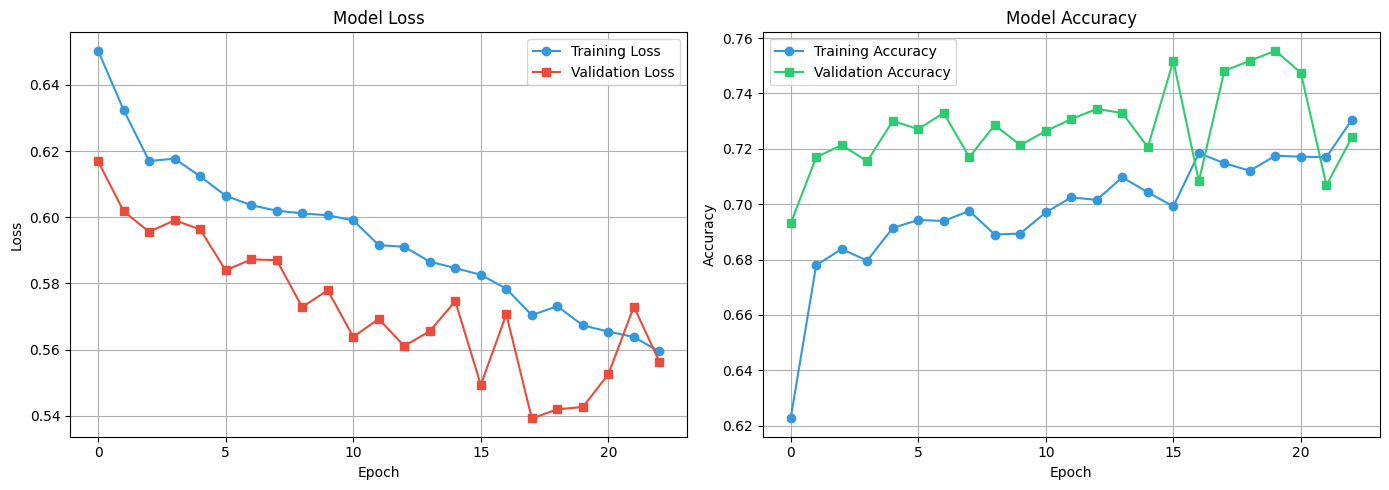

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Training Loss', marker='o', color='#3498db')
axes[0].plot(history.history['val_loss'], label='Validation Loss', marker='s', color='#e74c3c')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Training Accuracy', marker='o', color='#3498db')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s', color='#2ecc71')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

In [17]:
def predict_clickbait(title):
    """Prediksi apakah judul termasuk clickbait"""
    # Ekstraksi fitur
    features = extract_features(title)
    numeric_input = np.array([[features[f] for f in numeric_features]])
    numeric_scaled = scaler.transform(numeric_input)

    # Preprocessing teks
    clean = clean_text(title)
    text_seq = tokenizer.texts_to_sequences([clean])
    text_pad = sequence.pad_sequences(text_seq, maxlen=MAX_LEN, padding='post')

    # Prediksi
    prob = model.predict([text_pad, numeric_scaled], verbose=0)[0][0]
    pred = 1 if prob > 0.5 else 0

    return pred, prob

# Test
test_titles = [
    "VIRAL!!! Wanita ini bisa terbang, buktikan dengan klik video!",
    "Presiden Jokowi resmikan jalan tol baru di Jawa Barat",
    "GILA! Cara ini bikin kaya dalam semalam!!!",
    "DPR dan pemerintah sepakati anggaran pendidikan 2025"
]

print("_"*50)
print("HASIL PREDIKSI JUDUL BARU")
print("_"*50)

for title in test_titles:
    pred, prob = predict_clickbait(title)
    result = " CLICKBAIT" if pred == 1 else " NON-CLICKBAIT"
    print(f"\nJudul: {title}")
    print(f"Hasil: {result}")
    print(f"Probabilitas Clickbait: {prob:.4f}")
    print("-"*40)

__________________________________________________
HASIL PREDIKSI JUDUL BARU
__________________________________________________

Judul: VIRAL!!! Wanita ini bisa terbang, buktikan dengan klik video!
Hasil:  NON-CLICKBAIT
Probabilitas Clickbait: 0.2098
----------------------------------------

Judul: Presiden Jokowi resmikan jalan tol baru di Jawa Barat
Hasil:  CLICKBAIT
Probabilitas Clickbait: 0.5603
----------------------------------------

Judul: GILA! Cara ini bikin kaya dalam semalam!!!
Hasil:  NON-CLICKBAIT
Probabilitas Clickbait: 0.1779
----------------------------------------

Judul: DPR dan pemerintah sepakati anggaran pendidikan 2025
Hasil:  CLICKBAIT
Probabilitas Clickbait: 0.7845
----------------------------------------


In [18]:
# Simpan model dan preprocessor
model.save('clickbait_model.h5')

import joblib
joblib.dump(tokenizer, 'tokenizer.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

print(" Model dan preprocessor berhasil disimpan!")

# Download file
from google.colab import files
files.download('clickbait_model.h5')
files.download('tokenizer.pkl')
files.download('scaler.pkl')
files.download('label_encoder.pkl')

print(" File model telah diunduh!")

 Model dan preprocessor berhasil disimpan!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 File model telah diunduh!
